In [213]:

UNITS = 100               # - number of neurons
LEAK_RATE = 0.3           # - leaking rate
SPECTRAL_RADIUS = 1.25    # - spectral radius of W
INPUT_SCALING = 1.0       # - input scaling
RC_CONNECTIVITY = 0.1     # - density of reservoir internal matrix
INPUT_CONNECTIVITY = 0.2  # and of reservoir input matrix
REGULARIZATION = 1e-8     # - regularization coefficient for ridge regression
SEED = 1234               # for reproductibility

In [214]:
import numpy as np
import matplotlib.pyplot as plt

from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.datasets import mackey_glass

X = mackey_glass(2000)

# rescale between -1 and 1
X = 2 * (X - X.min()) / (X.max() - X.min()) - 1

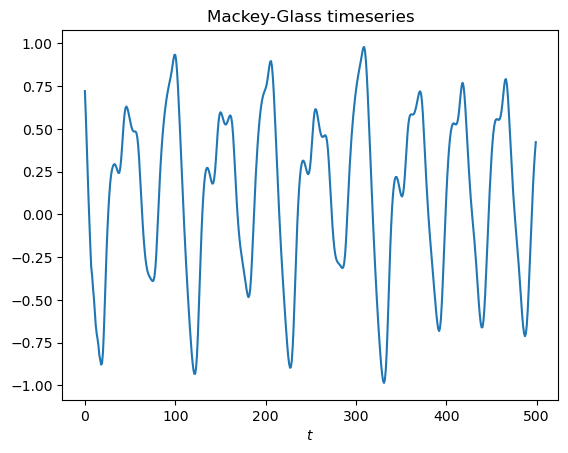

In [215]:
plt.figure()
plt.xlabel("$t$")
plt.title("Mackey-Glass timeseries")
plt.plot(X[:500])
plt.show()

In [216]:
states = []
spectral_radii = [0.1, 1.25, 10.0]
for spectral_radius in spectral_radii:
    reservoir = Reservoir(
        units=UNITS, 
        sr=spectral_radius, 
        input_scaling=INPUT_SCALING, 
        lr=LEAK_RATE, 
        rc_connectivity=RC_CONNECTIVITY,
        input_connectivity=INPUT_CONNECTIVITY,
        seed=SEED,
    )

    s = reservoir.run(X[:500])
    states.append(s)

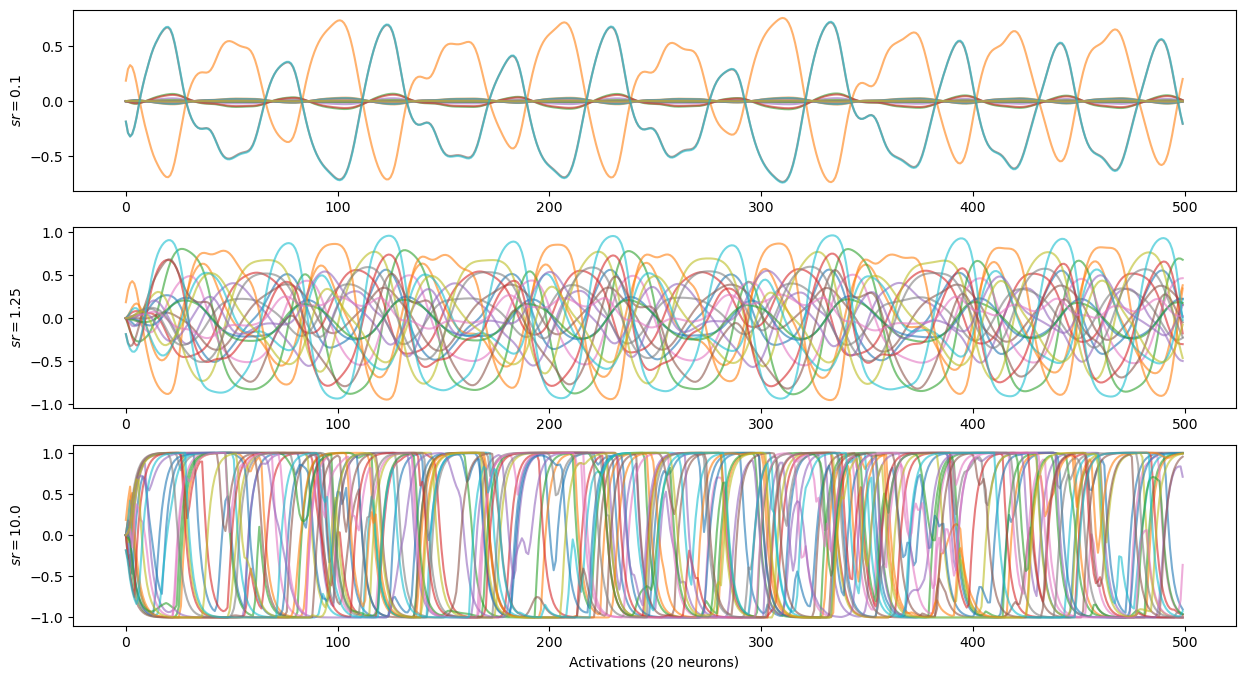

In [217]:
UNITS_SHOWN = 20

plt.figure(figsize=(15, 8))
for i, s in enumerate(states):
    plt.subplot(len(spectral_radii), 1, i+1)
    plt.plot(s[:, :UNITS_SHOWN], alpha=0.6)
    plt.ylabel(f"$sr={spectral_radii[i]}$")
plt.xlabel(f"Activations ({UNITS_SHOWN} neurons)")
plt.show()

In [218]:
states = []
input_scalings = [0.1, 1.0, 10.]
for input_scaling in input_scalings:
    reservoir = Reservoir(
        units=UNITS, 
        sr=SPECTRAL_RADIUS, 
        input_scaling=input_scaling, 
        lr=LEAK_RATE,
        rc_connectivity=RC_CONNECTIVITY, 
        input_connectivity=INPUT_CONNECTIVITY, 
        seed=SEED,
    )

    s = reservoir.run(X[:500])
    states.append(s)

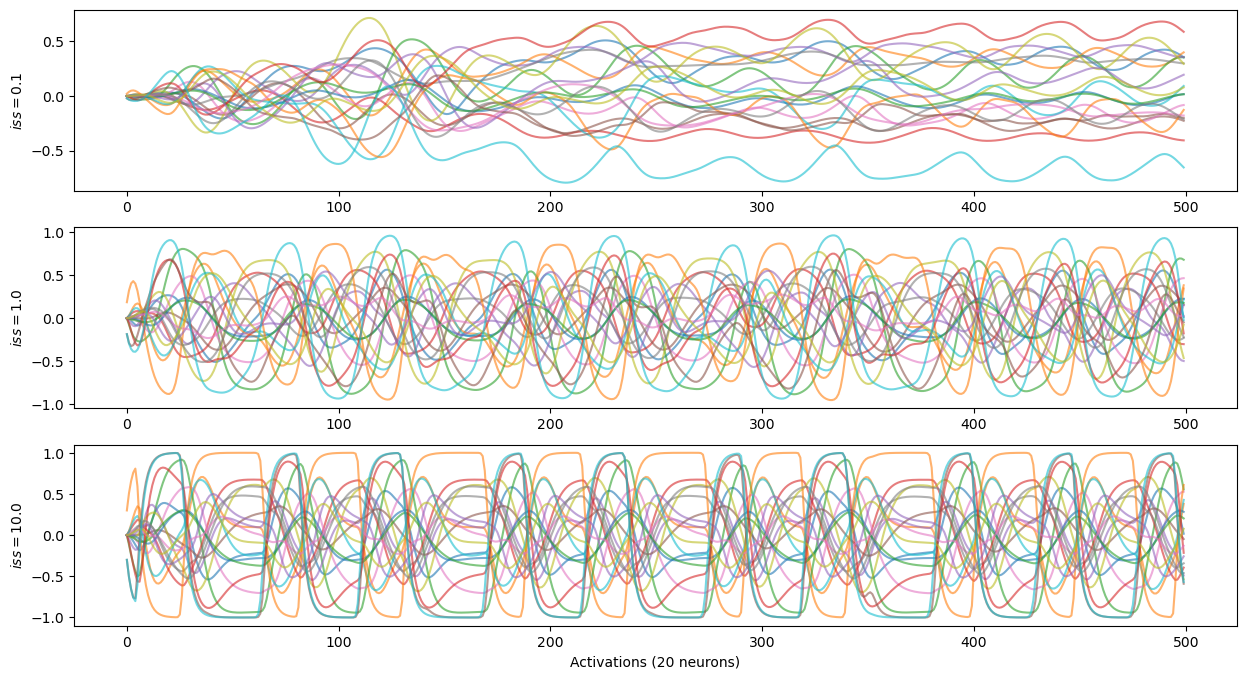

In [219]:
UNITS_SHOWN = 20

plt.figure(figsize=(15, 8))
for i, s in enumerate(states):
    plt.subplot(len(input_scalings), 1, i+1)
    plt.plot(s[:, :UNITS_SHOWN], alpha=0.6)
    plt.ylabel(f"$iss={input_scalings[i]}$")
plt.xlabel(f"Activations ({UNITS_SHOWN} neurons)")
plt.show()

In [220]:
diffusion_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_diffusion/01_connectomes/diffusion_10_percent.npy")
diffusion_matrices_10 = diffusion_matrices_10.T

propagation_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_10_percent.npy")
propagation_matrices_10 = propagation_matrices_10.T

routing_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_routing/01_connectomes/routing_10_percent.npy") 
routing_matrices_10 = routing_matrices_10.T

topology_matrices_10 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_topology/01_connectomes/topology_10_percent.npy") 
topology_matrices_10 = topology_matrices_10.T

diffusion_matrices_20 = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/kaysons_generated_networks_propagation/01_connectomes/propagation_20_percent_gen_by_kayson.npy")
diffusion_matrices_20 = diffusion_matrices_20[:,:,:1]

developing_matrices = np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/lexis_data_developing/01_connectomes/00_individual_connectomes_bin.npy")
developing_matrices = developing_matrices.T[:,:,:1]

A_arr = [diffusion_matrices_10,
         propagation_matrices_10,
         routing_matrices_10,
         topology_matrices_10,
         developing_matrices]

labels = ["Diffusion-10", "Propagation-10", "Routing-10", "Topology-10", "Developing"]

diffusion_matrices_10.shape, diffusion_matrices_20.shape, developing_matrices.shape

((100, 100, 1), (100, 100, 1), (100, 100, 1))

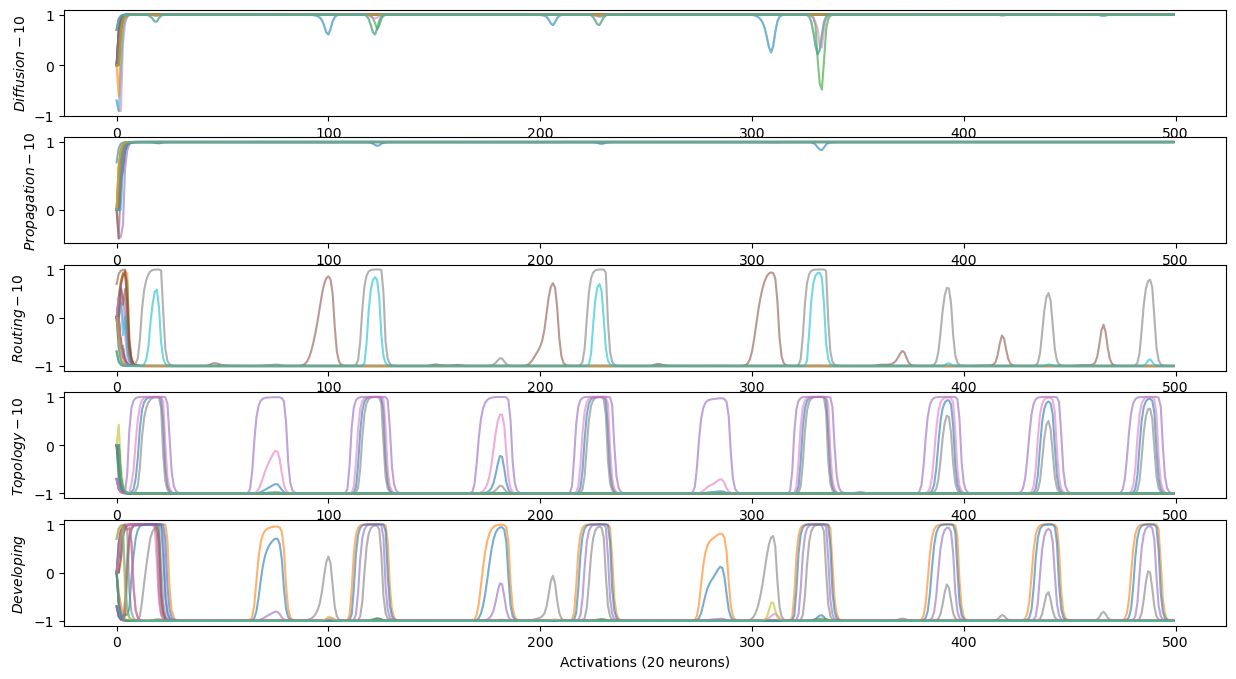

In [221]:
states = []
# input_scalings = [0.1, 1.0, 10.]
for A in A_arr: # input_scaling in input_scalings:
    reservoir = Reservoir(
        W=A[:,:,0], 
        # units=UNITS, 
        sr=0.99, # 1.2, #0.99, # SPECTRAL_RADIUS, 
        input_scaling=10, # INPUT_SCALING, 
        # # lr=0.4, # LEAK_RATE,
        # rc_connectivity=1, # 1, # RC_CONNECTIVITY, 
        # # input_connectivity=INPUT_CONNECTIVITY, 
        # seed=SEED,
        lr=0.7, # LEAK_RATE, 
        rc_connectivity=0.1, # 1, # RC_CONNECTIVITY, 
        input_connectivity=INPUT_CONNECTIVITY,
    )

    s = reservoir.run(X[:500])
    states.append(s)
    
UNITS_SHOWN = 20

plt.figure(figsize=(15, 8))
for i, s in enumerate(states):
    plt.subplot(len(A_arr), 1, i+1)
    plt.plot(s[:, :UNITS_SHOWN], alpha=0.6)
    plt.ylabel(f"${labels[i]}$")
plt.xlabel(f"Activations ({UNITS_SHOWN} neurons)")
plt.show()

In [222]:
from functools import partial
import src.analysis.utils_kayson_damicelli as ut
from sklearn.model_selection import train_test_split

In [292]:
lags=np.arange(1, 41)
X, y = ut.make_X_y(
    make_X=partial(np.random.uniform, low=0, high=1, size=3000),
    lags=lags,
    cut=0
)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=.2)
dataset = (X_train, X_test, y_train, y_test)

y_train_nonlinear = y_train**2
y_test_nonlinear = y_test**2
X_train.shape, X_test.shape, y_train.shape, y_test.shape, y_train_nonlinear.shape, y_test_nonlinear.shape

((2400, 1), (600, 1), (2400, 40), (600, 40), (2400, 40), (600, 40))

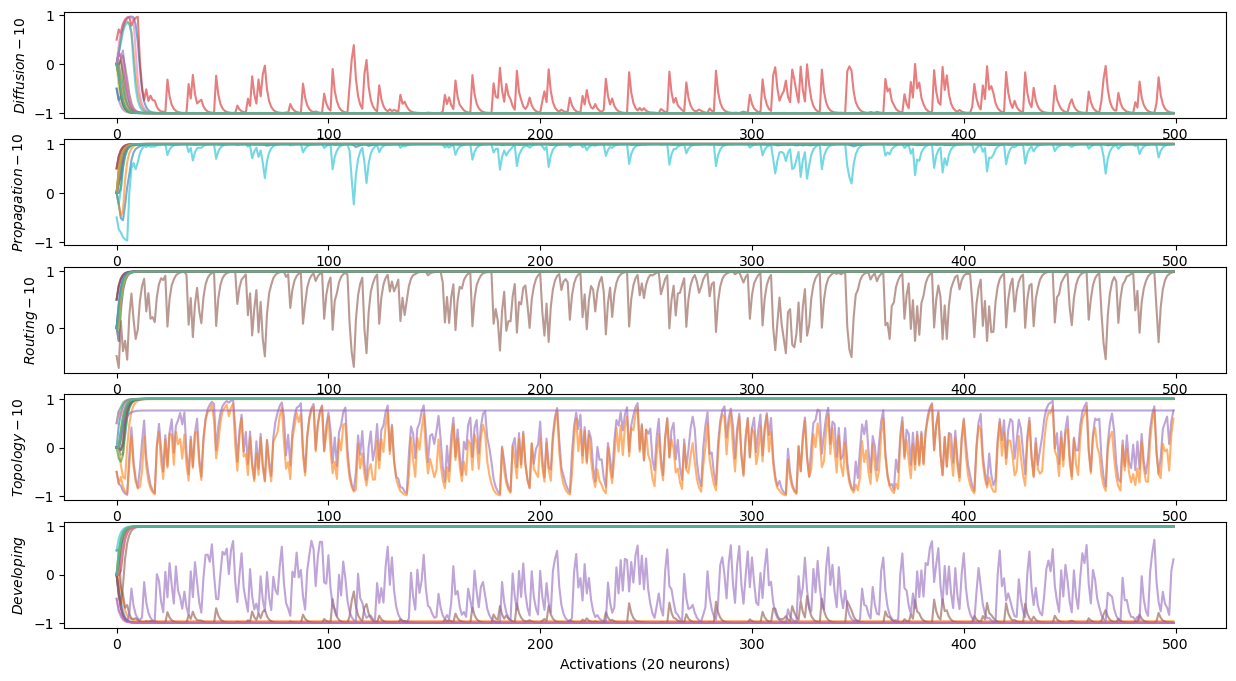

In [295]:
states = []
# input_scalings = [0.1, 1.0, 10.]
for A in A_arr: # input_scaling in input_scalings:
    reservoir = Reservoir(
        W=A[:,:,0], 
        # units=UNITS, 
        sr=0.95, # 1.2, #0.99, # SPECTRAL_RADIUS, 
        input_scaling=10, # e-5, # INPUT_SCALING, 
        # # lr=0.4, # LEAK_RATE,
        # rc_connectivity=1, # 1, # RC_CONNECTIVITY, 
        # # input_connectivity=INPUT_CONNECTIVITY, 
        # seed=SEED,
        lr=0.5, # 1, # 1, # 4, # 7, # LEAK_RATE, 
        rc_connectivity=1, # 0.1, # 1, # RC_CONNECTIVITY, 
        input_connectivity=INPUT_CONNECTIVITY,
    )

    s = reservoir.run(X_train[:500])
    states.append(s)
    
UNITS_SHOWN = 20

plt.figure(figsize=(15, 8))
for i, s in enumerate(states):
    plt.subplot(len(A_arr), 1, i+1)
    plt.plot(s[:, :UNITS_SHOWN], alpha=0.6)
    plt.ylabel(f"${labels[i]}$")
plt.xlabel(f"Activations ({UNITS_SHOWN} neurons)")
plt.show()

In [171]:
from reservoirpy.observables import nrmse, rsquare

In [192]:
# Objective functions accepted by ReservoirPy must respect some conventions:
#  - dataset and config arguments are mandatory, like the empty '*' expression.
#  - all parameters that will be used during the search must be placed after the *.
#  - the function must return a dict with at least a 'loss' key containing the result
# of the loss function. You can add any additional metrics or information with other
# keys in the dict. See hyperopt documentation for more informations.
def objective(dataset,
              config, *, input_scaling, N, sr, lr, ridge, seed):

    x_train, x_test, y_train, y_test = dataset

    # You can access anything you put in the config
    # file from the 'config' parameter.
    instances = config["instances_per_trial"]
    # W = config["W"]

    # The seed should be changed across the instances,
    # to be sure there is no bias in the results
    # due to initialization.
    variable_seed = seed

    losses = []; r2s = [];
    for n in range(instances):
        # Build your model given the input parameters
        reservoir = Reservoir(
            W=A[:,:,0], # CHEAT!!!
            sr=sr,
            lr=lr,
            input_scaling=input_scaling,
            seed=variable_seed
        )

        readout = Ridge(ridge=ridge)

        model = reservoir >> readout


        # Train your model and test your model.
        predictions = model.fit(x_train, y_train) \
                           .run(x_test)

        loss = nrmse(y_test, predictions, norm_value=np.ptp(x_train))
        r2 = rsquare(y_test, predictions)

        # Change the seed between instances
        variable_seed += 1

        losses.append(loss)
        r2s.append(r2)

    # Return a dictionnary of metrics. The 'loss' key is mandatory when
    # using hyperopt.
    return {'loss': np.mean(losses),
            'r2': np.mean(r2s)}

In [199]:
import json

hyperopt_config = {
    "exp": "hyperopt-multiscroll",    # the experimentation name
    "hp_max_evals": 200,              # the number of differents sets of parameters hyperopt has to try
    "hp_method": "random",            # the method used by hyperopt to chose those sets (see below)
    "seed": 42,                       # the random state seed, to ensure reproducibility
    "instances_per_trial": 5,         # how many random ESN will be tried with each sets of parameters
    "hp_space": {                     # what are the ranges of parameters explored
        "N": ["choice", 100],             # the number of neurons is fixed to 500
        "sr": ["loguniform", 1e-2, 10],   # the spectral radius is log-uniformly distributed between 1e-2 and 10
        "lr": ["loguniform", 1e-2, 1],    # idem with the leaking rate, from 1e-3 to 1
        "input_scaling": ["choice", 1.0], # the input scaling is fixed
        "ridge": ["loguniform", 1e-8, 1e1],        # and so is the regularization parameter.
        "seed": ["choice", 1234]          # an other random seed for the ESN initialization
    }
}

# we precautionously save the configuration in a JSON file
# each file will begin with a number corresponding to the current experimentation run number.
with open(f"{hyperopt_config['exp']}.config.json", "w+") as f:
    json.dump(hyperopt_config, f)

In [200]:
from reservoirpy.hyper import research
best = research(objective, dataset, f"{hyperopt_config['exp']}.config.json", ".")

100%|██████████| 200/200 [00:33<00:00,  5.92trial/s, best loss: 0.2926944705240838]


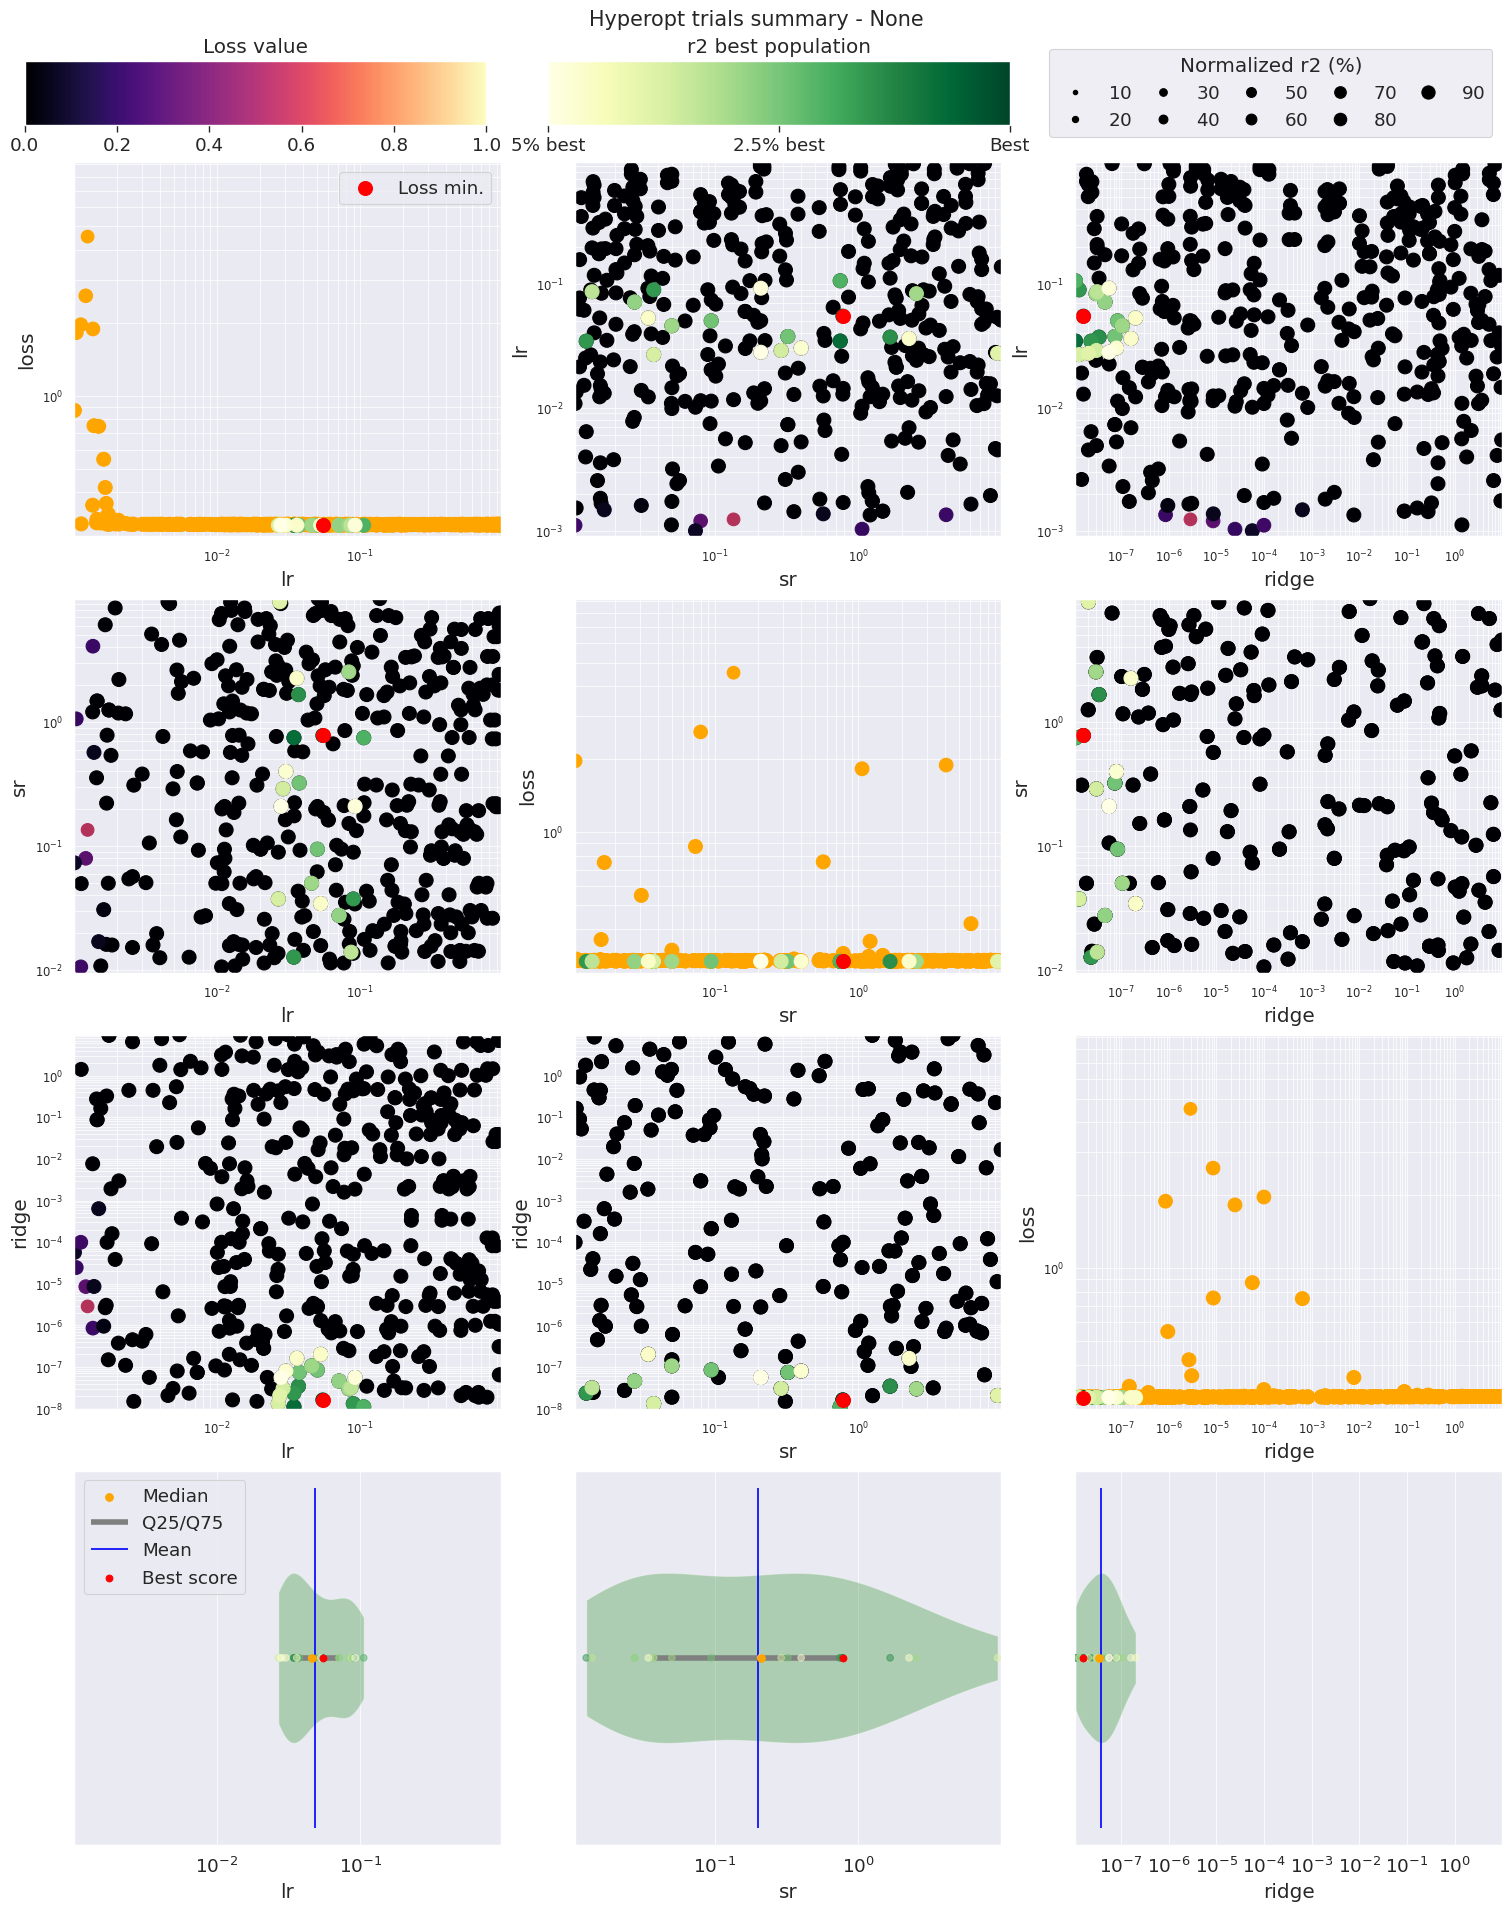

In [201]:
from reservoirpy.hyper import plot_hyperopt_report
fig = plot_hyperopt_report(hyperopt_config["exp"], ("lr", "sr", "ridge"), metric="r2")